In [ ]:
import matplotlib.pyplot as plt
import torch
import librosa
import numpy as np
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import utils

# 1. Load the model and processor
# (musicgen-small works great for extracting attention weights without using too much VRAM)
processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
model = MusicgenForConditionalGeneration.from_pretrained(
    "facebook/musicgen-small",
    attn_implementation="eager"
)


# 2. Load and preprocess your song (or an audio snippet)
# MusicGen expects a sampling rate of 32,000 Hz
audio_path = "../music-clips/bleep.wav"  # Replace with your song file
audio, sr = librosa.load(audio_path, sr=32000, duration=60.0)  # Analyze the first 60 seconds

# Preprocess the audio and an optional text query to guide the cross-attention analysis
inputs = processor(
    audio=audio,
    sampling_rate=sr,
    text=[""],  # Optional text to analyze cross-attention alignments
    padding=True,
    return_tensors="pt"
)

# 3. Encode audio and get decoder input tokens
with torch.no_grad():
    audio_features = inputs["input_values"]
    decoder_input_ids = model.audio_encoder.encode(audio_features).audio_codes

    # Dummy conditioning to match the decoder input shape expected by the model
    batch_size = decoder_input_ids.shape[0]
    dummy_encoder_hidden_states = torch.zeros(
        batch_size,
        1,
        1024,  # musicgen-small hidden size
        device=decoder_input_ids.device
    )

    # Run the decoder and collect attention maps for each layer
    decoder_outputs = model.decoder(
        input_ids=decoder_input_ids,
        encoder_hidden_states=dummy_encoder_hidden_states,
        output_attentions=True,
        return_dict=True
    )

# 4. Extract self-attention maps from each decoder layer
self_attentions = decoder_outputs.attentions

print(f"Success! Number of self-attention layers: {len(self_attentions)}")
print(f"Layer 0 shape: {self_attentions[0].shape}")

# 5. Keep only the entries corresponding to Codebook 0
# In this token layout, Codebook 0 appears every 4 positions.
sequence_length = self_attentions[0].shape[-1]
codebook_step = 4
codebook_0_indices = torch.arange(0, sequence_length, step=codebook_step, device=self_attentions[0].device)

layerwise_codebook0_attention = []
for layer_attention in self_attentions:
    codebook0_attention = layer_attention[:, :, codebook_0_indices[:, None], codebook_0_indices]
    layerwise_codebook0_attention.append(codebook0_attention)

# 6. Stack the selected attention maps across layers
# Shape: (num_layers, batch_size, num_heads, sequence_length, sequence_length)
cb0_stacked_attention = torch.stack(layerwise_codebook0_attention, dim=0)


Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

Success! Number of self-attention layers: 24
Layer 0 shape: torch.Size([1, 16, 1503, 1503])


In [13]:
mean_distances_seconds = utils.compute_mad_by_layer(cb0_stacked_attention, cb0_stacked_attention.shape[-1])

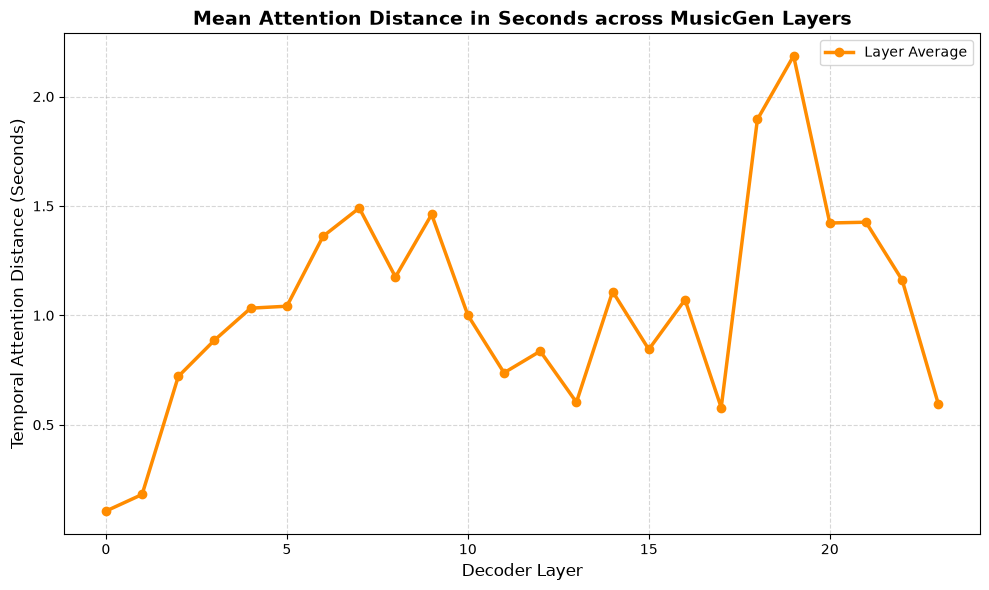

In [14]:
utils.plot_mad(mean_distances_seconds, cb0_stacked_attention[0].shape[1])
plt.show()

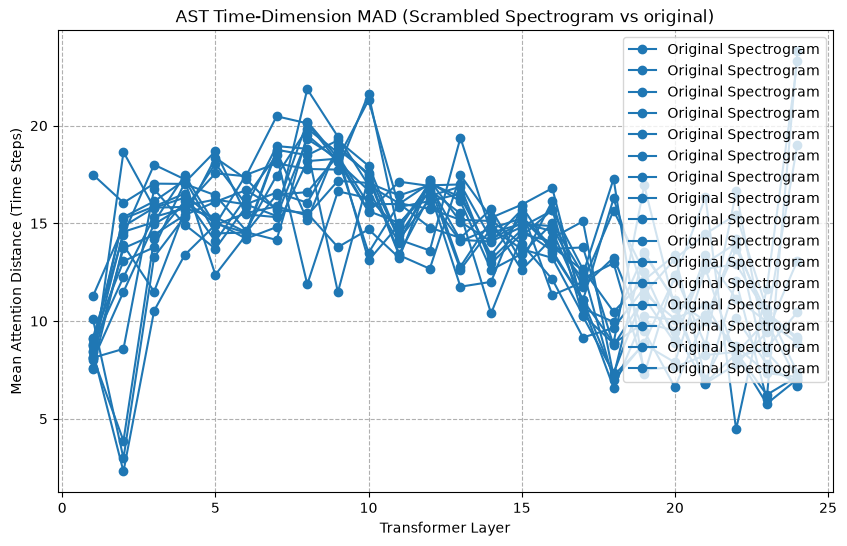

In [5]:
layers = np.arange(1, 25)
plt.figure(figsize=(10, 6))
plt.plot(layers, mean_distances_seconds, marker='o', color='#1f77b4', label='Original Spectrogram')
plt.title('AST Time-Dimension MAD (Scrambled Spectrogram vs original)')
plt.xlabel('Transformer Layer')
plt.ylabel('Mean Attention Distance (Time Steps)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()